In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

2. Завантаження даних

In [69]:
df = pd.read_csv('../data/raw/alarms/alarms-240222-010325.csv', sep = ';')
print(f"Розмір датасету: {df.shape[0]} рядків, {df.shape[1]} колонок")

Розмір датасету: 55788 рядків, 6 колонок


3. Перші 5 рядків датасету

In [70]:
df.head()

,id,region_id,region_city,all_region,start,end
0,52432,12,Львівська обл.,1,2022-02-24 07:43:17,2022-02-24 09:52:28
1,53292,23,Чернігівська обл.,1,2022-02-24 14:00:43,2022-02-24 17:11:43
2,52080,3,Вінницька обл.,1,2022-02-24 15:40:42,2022-02-24 16:10:42
3,52857,19,Харківська обл.,1,2022-02-24 20:11:47,2022-02-24 20:59:47
4,52700,18,Тернопільська обл.,1,2022-02-25 01:59:36,2022-02-25 09:00:19


Опис колонок
id - ідентифікатор конкретного запису про тривогу
region_id - цифровий ідентифікатор регіону.
region_city - назва області, де оголошено загрозу.
all_region - індикатор, який показує, чи поширюється тривога на всю область повністю
start - точна дата та час початку тривоги.
end - точна дата та час закінчення тривоги.

4. Типи даних

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55788 entries, 0 to 55787
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           55788 non-null  int64 
 1   region_id    55788 non-null  int64 
 2   region_city  55788 non-null  object
 3   all_region   55788 non-null  int64 
 4   start        55788 non-null  object
 5   end          55788 non-null  object
dtypes: int64(3), object(3)
memory usage: 2.6+ MB


Колонки start та end наразі мають текстовий тип даних object, замість потрібного часового формату datetime. Щоб мати змогу проводити часовий аналіз, на наступних етапах ці колонки необхідно буде конвертувати у формат datetime.

5. Описова статистика

In [72]:
df.describe()

,id,region_id,all_region
count,55788.000000,55788.000000,55788.000000
mean,109103.029935,12.178121,0.972180
std,38574.559928,6.474089,0.164457
min,1.000000,1.000000,0.000000
25%,68259.750000,6.000000,1.000000
50%,126918.500000,13.000000,1.000000
75%,143399.250000,19.000000,1.000000
max,158665.000000,25.000000,1.000000


Аналіз описової статистики (min/max/mean)
* **all_region (Охоплення загрози):**
  * Mean (0.97): Середнє значення 0.97 означає, що у 97.2% випадків тривога оголошується відразу на всю область.
  * Min (0.0) / Max (1.0): Підтверджує, що це бінарний прапорець (0 це загроза для окремої громади, 1 це для всього регіону).
* **region_id (Географія):**
  * Min (1.0) / Max (25.0): Діапазон значень відповідає адміністративному поділу України (24 області + місто Київ). Це доводить, що ми маємо покриття по всій країні без аномалій.
* **id (Кількість подій):**
  * Хоча загальна кількість тривог у датасеті становить 55,788, Max значення ID досягає 158,665. Це може свідчити про те, що першоджерело містило більше записів, які були відфільтровані при формуванні цього CSV.

6-7. Пропуски та дублікати

In [73]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
print(pd.DataFrame({'Пропуски': missing, 'Відсоток': missing_pct.round(2)}))

             Пропуски  Відсоток
id                  0       0.0
region_id           0       0.0
region_city         0       0.0
all_region          0       0.0
start               0       0.0
end                 0       0.0


Так як у датафреймі тільки 0, тому датасет чистий

In [74]:
df.duplicated().sum()

0

По тій же причині все чисто

8. Категоріальні колонки (Топ-10 регіонів за кількістю тривог)

In [75]:
df['region_city'].value_counts().head(10)

region_city
Донецька обл.            5886
Харківська обл.          5652
Запорізька обл.          5494
Дніпропетровська обл.    4966
Полтавська обл.          3499
Сумська обл.             3251
Миколаївська обл.        3123
Херсонська обл.          3031
Кіровоградська обл.      2913
Черкаська обл.           2119
Name: count, dtype: int64

В Донецькій, Харківській та Запорізькій області тривог найбільше

9. Конвертація дат та створення нових часових колонок

In [76]:
df['start'] = pd.to_datetime(df['start'])
df['end'] = pd.to_datetime(df['end'])
df['hour'] = df['start'].dt.hour
df['day_of_week'] = df['start'].dt.dayofweek
df['month'] = df['start'].dt.month
df['year'] = df['start'].dt.year
df[['start', 'end', 'hour', 'day_of_week', 'month', 'year']].head()

,start,end,hour,day_of_week,month,year
0,2022-02-24 07:43:17,2022-02-24 09:52:28,7,3,2,2022
1,2022-02-24 14:00:43,2022-02-24 17:11:43,14,3,2,2022
2,2022-02-24 15:40:42,2022-02-24 16:10:42,15,3,2,2022
3,2022-02-24 20:11:47,2022-02-24 20:59:47,20,3,2,2022
4,2022-02-25 01:59:36,2022-02-25 09:00:19,1,4,2,2022


Дані конвертовано в datetime

Погода і дані

In [77]:
df_weather = pd.read_csv('../data/raw/weather/historical/all_weather_by_hour_2023-2025_v1.csv')
print(f"Розмір датасету погоди: {df_weather.shape[0]} рядків, {df_weather.shape[1]} колонок\n")
print(df_weather.isnull().sum())
df_weather.head()

Розмір датасету погоди: 608304 рядків, 65 колонок

city_latitude              0
city_longitude             0
city_resolvedAddress       0
city_address               0
city_timezone              0
                        ... 
hour_uvindex            4336
hour_conditions            0
hour_icon                  0
hour_source                0
hour_stations              0
Length: 65, dtype: int64


,city_latitude,city_longitude,city_resolvedAddress,city_address,city_timezone,city_tzoffset,day_datetime,day_datetimeEpoch,day_tempmax,day_tempmin,...,hour_pressure,hour_visibility,hour_cloudcover,hour_solarradiation,hour_solarenergy,hour_uvindex,hour_conditions,hour_icon,hour_source,hour_stations
0,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,...,1020.0,0.0,91.5,0.0,NaN,0.0,Overcast,snow,obs,remote
1,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,...,1021.0,0.2,88.2,0.0,NaN,0.0,Partially cloudy,fog,obs,remote
2,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,...,1022.0,10.0,100.0,NaN,NaN,NaN,Overcast,cloudy,obs,33177099999
3,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,...,1021.0,0.1,92.0,0.0,NaN,0.0,Overcast,fog,obs,remote
4,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,...,1021.0,0.0,93.8,0.0,NaN,0.0,Overcast,cloudy,obs,remote


In [78]:
print(df_weather.columns.tolist())

['city_latitude', 'city_longitude', 'city_resolvedAddress', 'city_address', 'city_timezone', 'city_tzoffset', 'day_datetime', 'day_datetimeEpoch', 'day_tempmax', 'day_tempmin', 'day_temp', 'day_feelslikemax', 'day_feelslikemin', 'day_feelslike', 'day_dew', 'day_humidity', 'day_precip', 'day_precipprob', 'day_precipcover', 'day_snow', 'day_snowdepth', 'day_windgust', 'day_windspeed', 'day_winddir', 'day_pressure', 'day_cloudcover', 'day_visibility', 'day_solarradiation', 'day_solarenergy', 'day_uvindex', 'day_sunrise', 'day_sunriseEpoch', 'day_sunset', 'day_sunsetEpoch', 'day_moonphase', 'day_conditions', 'day_description', 'day_icon', 'day_source', 'day_preciptype', 'day_stations', 'hour_datetime', 'hour_datetimeEpoch', 'hour_temp', 'hour_feelslike', 'hour_humidity', 'hour_dew', 'hour_precip', 'hour_precipprob', 'hour_snow', 'hour_snowdepth', 'hour_preciptype', 'hour_windgust', 'hour_windspeed', 'hour_winddir', 'hour_pressure', 'hour_visibility', 'hour_cloudcover', 'hour_solarradiation

In [79]:
columns_main = [
    'city_address',
    'hour_datetime',
    'hour_temp',
    'hour_humidity',
    'hour_precip',
    'hour_snow',
    'hour_windgust',
    'hour_windspeed',
    'hour_visibility',
    'hour_cloudcover',
    'hour_conditions'
]
df_weather = df_weather[columns_main]
df_weather['hour_datetime'] = pd.to_datetime(df_weather['hour_datetime'])
print(f"Новий розмір датасету: {df_weather.shape[0]} рядків, {df_weather.shape[1]} колонок")
df_weather.head()

Новий розмір датасету: 608304 рядків, 11 колонок


/var/folders/n2/f3yfs41x57x44f6254hp51fc0000gn/T/ipykernel_75025/4155430299.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_weather['hour_datetime'] = pd.to_datetime(df_weather['hour_datetime'])


,city_address,hour_datetime,hour_temp,hour_humidity,hour_precip,hour_snow,hour_windgust,hour_windspeed,hour_visibility,hour_cloudcover,hour_conditions
0,"Lutsk,Ukraine",2026-03-05 00:00:00,2.4,89.18,0.0,0.1,31.3,15.5,0.0,91.5,Overcast
1,"Lutsk,Ukraine",2026-03-05 01:00:00,2.4,87.90,0.0,0.0,27.7,14.8,0.2,88.2,Partially cloudy
2,"Lutsk,Ukraine",2026-03-05 02:00:00,2.9,88.58,0.0,0.0,29.2,14.4,10.0,100.0,Overcast
3,"Lutsk,Ukraine",2026-03-05 03:00:00,2.3,86.63,0.0,0.0,23.8,13.3,0.1,92.0,Overcast
4,"Lutsk,Ukraine",2026-03-05 04:00:00,1.9,87.85,0.0,0.0,24.5,13.3,0.0,93.8,Overcast


3-5. Огляд погодних даних, типи та статистика

In [80]:
df_weather.info()
df_weather.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 608304 entries, 0 to 608303
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   city_address     608304 non-null  object        
 1   hour_datetime    608304 non-null  datetime64[ns]
 2   hour_temp        608304 non-null  float64       
 3   hour_humidity    608304 non-null  float64       
 4   hour_precip      608202 non-null  float64       
 5   hour_snow        608304 non-null  float64       
 6   hour_windgust    608304 non-null  float64       
 7   hour_windspeed   608304 non-null  float64       
 8   hour_visibility  331846 non-null  float64       
 9   hour_cloudcover  608304 non-null  float64       
 10  hour_conditions  608304 non-null  object        
dtypes: datetime64[ns](1), float64(8), object(2)
memory usage: 51.1+ MB


,hour_datetime,hour_temp,hour_humidity,hour_precip,hour_snow,hour_windgust,hour_windspeed,hour_visibility,hour_cloudcover
count,608304,608304.000000,608304.000000,608202.000000,608304.000000,608304.000000,608304.000000,331846.000000,608304.000000
mean,2026-03-05 11:29:59.999999488,10.719390,72.891267,0.087357,0.005045,23.769943,11.399938,17.010448,64.811065
min,2026-03-05 00:00:00,-50.300000,8.460000,0.000000,0.000000,0.700000,0.000000,0.000000,0.000000
25%,2026-03-05 05:45:00,2.400000,59.310000,0.000000,0.000000,14.800000,7.200000,10.000000,30.000000
50%,2026-03-05 11:30:00,10.200000,77.430000,0.000000,0.000000,22.300000,10.800000,15.800000,80.000000
75%,2026-03-05 17:15:00,18.400000,89.050000,0.000000,0.000000,31.000000,15.100000,24.100000,99.900000
max,2026-03-05 23:00:00,60.400000,100.000000,300.000000,4.200000,230.400000,90.000000,75.000000,100.000000
std,NaN,9.787529,19.456422,2.141735,0.048299,11.492758,6.517607,9.656796,37.318628


**Висновки з огляду погодних даних:**
1. **Пропуски:** Колонка hour_visibility має майже 50% пропущених значень (331,846 із 608,304). Також є незначна кількість пропусків у даних про опади.
2. **Аномалії (Викиди):** У статистиці спостерігаються нереалістичні для України значення. Наприклад, температура hour_temp має діапазон від -50.3 до +60.4 градусів, а пориви вітру досягають 230 км/год. Це свідчить про наявність системних помилок, які потрібно буде враховувати при побудові графіків.

6-7. Перевірка на пропуски та дублікати

In [81]:
print(df_weather.isnull().sum())
print(f"Кількість повних дублікатів: {df_weather.duplicated().sum()}")

city_address            0
hour_datetime           0
hour_temp               0
hour_humidity           0
hour_precip           102
hour_snow               0
hour_windgust           0
hour_windspeed          0
hour_visibility    276458
hour_cloudcover         0
hour_conditions         0
dtype: int64
Кількість повних дублікатів: 4


Виявлено 4 дубльовані рядки, які треба видалити. Колонка hour_precip має незначну кількість пропусків (102), що не є критичним. Проте колонка hour_visibility містить 276 458 пропусків. Це потрібно враховувати при подальшому аналізі та побудові графіків.

8-9. Видалення дублікатів, категоріальні колонки та конвертація дат

In [82]:
df_weather = df_weather.drop_duplicates()
print("ТОП-10 міст за кількістю записів")
print(df_weather['city_address'].value_counts().head(10))
df_weather['hour'] = df_weather['hour_datetime'].dt.hour
df_weather['day_of_week'] = df_weather['hour_datetime'].dt.dayofweek
df_weather['month'] = df_weather['hour_datetime'].dt.month
df_weather['year'] = df_weather['hour_datetime'].dt.year
df_weather[['hour_datetime', 'hour', 'day_of_week', 'month', 'year']].head()

ТОП-10 міст за кількістю записів
city_address
Lutsk,Ukraine              26448
Uzhgorod,Ukraine           26448
Sumy,Ukraine               26448
Cherkasy,Ukraine           26448
Ivano-Frankivsk,Ukraine    26448
Lviv,Ukraine               26448
Poltava,Ukraine            26448
Ternopil,Ukraine           26448
Zhytomyr,Ukraine           26448
Rivne,Ukraine              26448
Name: count, dtype: int64


,hour_datetime,hour,day_of_week,month,year
0,2026-03-05 00:00:00,0,3,3,2026
1,2026-03-05 01:00:00,1,3,3,2026
2,2026-03-05 02:00:00,2,3,3,2026
3,2026-03-05 03:00:00,3,3,3,2026
4,2026-03-05 04:00:00,4,3,3,2026


Для кожного міста є рівно по 26 448 годинних записів погоди. Дані готові до роботи.

In [83]:
df_regions = pd.read_csv('../data/raw/alarms/regions.csv')
regions_count = df_regions.shape[0]
print(f"Кількість регіонів: {regions_count}")

if regions_count == 25:
    print("Аномалій не знайдено.")
else:
    print("Знайдено пасхалку: аномальна кількість регіонів")
display(df_regions.head())

Кількість регіонів: 25
Аномалій не знайдено.


,region,center_city_ua,center_city_en,region_alt,region_id
0,АР Крим,Сімферополь,Simferopol,Крим,1
1,Вінницька,Вінниця,Vinnytsia,Вінниччина,2
2,Волинська,Луцьк,Lutsk,Волинь,3
3,Дніпропетровська,Дніпро,Dnipro,Дніпропетровщина,4
4,Донецька,Донецьк,Donetsk,Донеччина,5


In [84]:
df = df.merge(df_regions, on = 'region_id', how = 'left')
print(f"Розмір таблиці тривог після мержу: {df.shape}")

Розмір таблиці тривог після мержу: (55788, 14)


Для коректної візуалізації графіків та майбутнього об'єднання з погодними даними було завантажено файл regions.csv. Перевірка підтвердила наявність 25 регіонів. Довідник приєднано через left merge до основного датасету тривог по ключу region_id.

4.2 Графіки з поясненнями
**Графік 1. Кількість тривог по областях**
Потрібно візуалізувати частоту оголошення тривог у різних регіонах України та порівняти показники прикордонних/фронтових областей із внутрішніми.

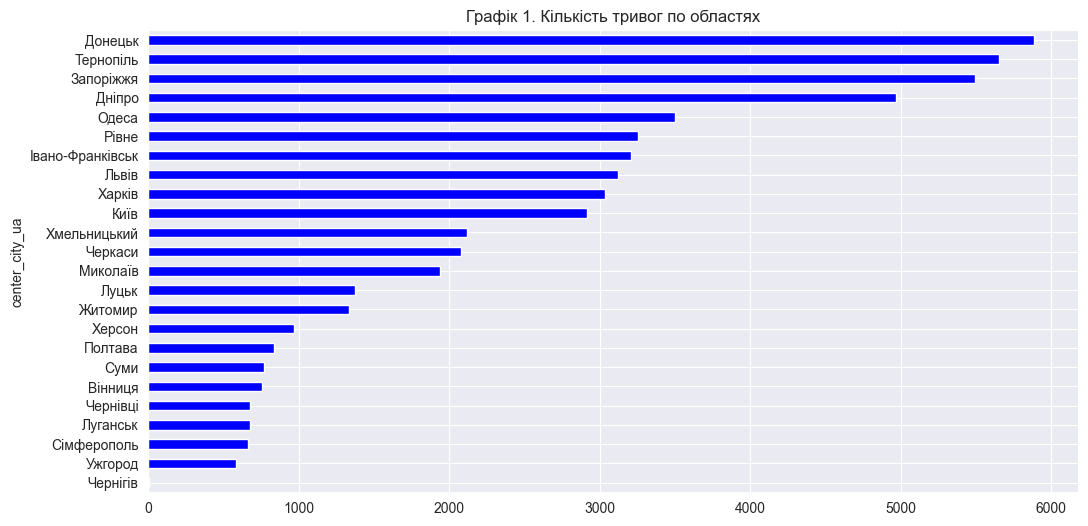

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.makedirs('plots', exist_ok=True)
sns.set_style("darkgrid")

df['center_city_ua'].value_counts().sort_values().plot(
    kind = 'barh',
    figsize = (12, 6),
    color = 'blue',
    title = 'Графік 1. Кількість тривог по областях'
)
plt.savefig('plots/01_alarms_horizontal.png', bbox_inches='tight')
plt.show()

**Висновок до Графіка 1**
Графік успішно побудовано, проте візуальний аналіз виявив критичну аномалію: лідерами за кількістю тривог після Донеччини виступають тилові західні регіони (Тернопіль, Рівне, Івано-Франківськ, Львів), тоді як прикордонні та фронтові області (Харків, Суми, Чернігів) знаходяться наприкінці списку. Це повністю суперечить реальній статистиці війни і свідчить про те, що у наданому файлі regions.csv навмисно змінені region_id. Відповідно, за цим датасетом внутрішні регіони страждають більше, але це аномалія.

In [86]:
print(df.columns.tolist())

['id', 'region_id', 'region_city', 'all_region', 'start', 'end', 'hour', 'day_of_week', 'month', 'year', 'region', 'center_city_ua', 'center_city_en', 'region_alt']


Графік 2. Тривоги по годинах доби
Треба визначити, у який час доби найчастіше оголошуються тривоги та знайти найнебезпечніші і найспокійніші години.

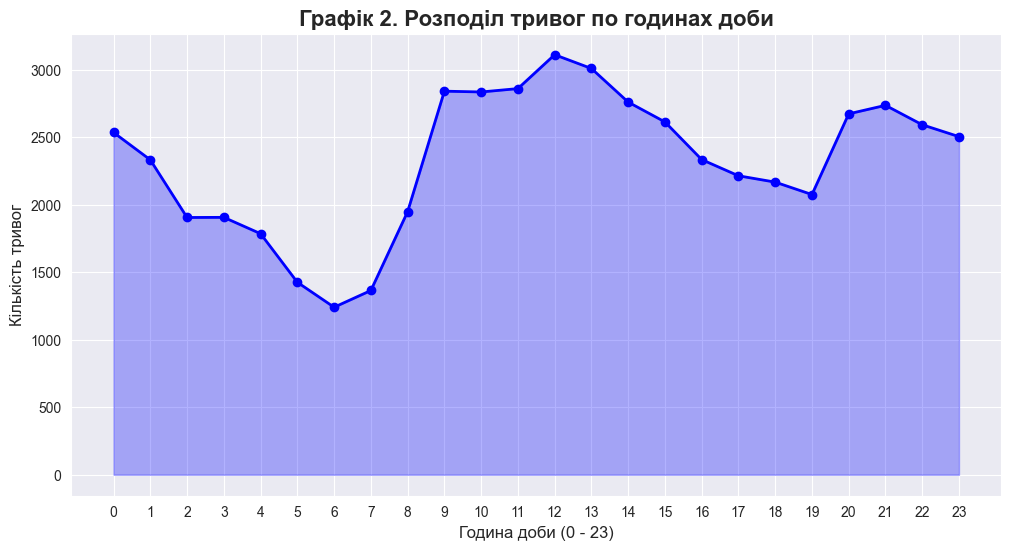

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns
hourly_count = df['hour'].value_counts().sort_index()
plt.figure(figsize = (12, 6))
sns.set_style("darkgrid")
plt.plot(hourly_count.index, hourly_count.values, color = 'blue', linewidth = 2, marker = 'o')
plt.fill_between(hourly_count.index, hourly_count.values, color = 'blue', alpha = 0.3)

plt.title('Графік 2. Розподіл тривог по годинах доби', fontsize = 16, fontweight = 'bold')
plt.xlabel('Година доби (0 - 23)', fontsize = 12)
plt.ylabel('Кількість тривог', fontsize = 12)
plt.xticks(range(0, 24))
plt.savefig('plots/02_alarms_by_hour.png', bbox_inches = 'tight')
plt.show()

**Висновок до Графіка 2:**
Аналіз розподілу тривог за годинами доби демонструє чітку добову циклічність. Найменша кількість тривог фіксується близько 06:00 ранку, що зазвичай є періодом затишшя після закінчення нічних атак БПЛА. Натомість абсолютний пік кількості тривог припадає на денний час (від 12:00 до 14:00). Це яскраво корелює з типовим часом активності ворожої розвідувальної авіації, тренувальними або бойовими злетами МіГ-31К (які спричиняють масштабні тривоги), а також загальною активністю тактичної авіації вздовж лінії фронту.

Графік 3. Тривоги по днях тижня
Треба виявити чи існує залежність між днем тижня та кількістю оголошених повітряних тривог (порівняння буднів та вихідних).

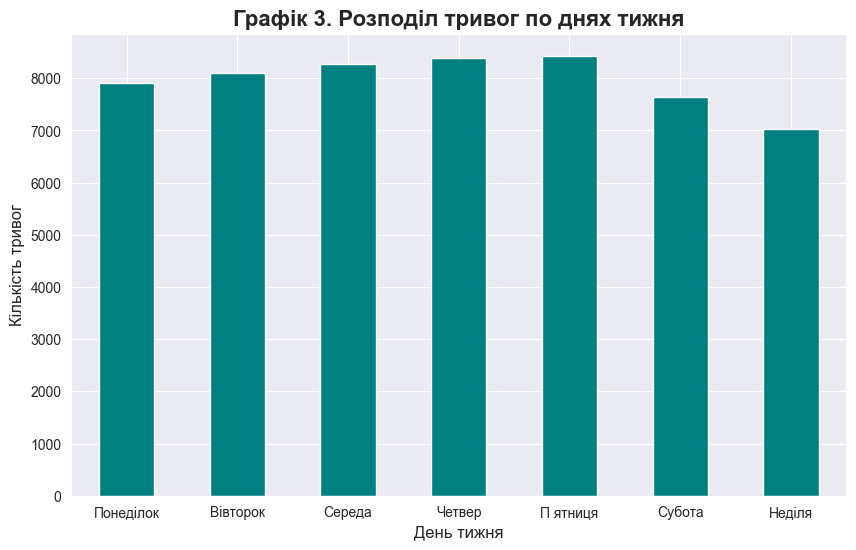

In [88]:
import matplotlib.pyplot as plt
days_map = {0: 'Понеділок', 1: 'Вівторок', 2: 'Середа', 3: 'Четвер', 4: 'П ятниця', 5: 'Субота', 6: 'Неділя'}
day_count = df['day_of_week'].value_counts().sort_index()
day_count.index = day_count.index.map(days_map)
plt.figure(figsize=(10, 6))
day_count.plot(kind='bar', color='teal')

plt.title('Графік 3. Розподіл тривог по днях тижня', fontsize = 16, fontweight ='bold')
plt.xlabel('День тижня', fontsize=12)
plt.ylabel('Кількість тривог', fontsize=12)
plt.xticks(rotation=0)

plt.savefig('plots/03_alarms_by_day.png', bbox_inches='tight')
plt.show()

**Висновок до Графіка 3:**
Аналіз демонструє наступне. Найбільша кількість тривог зафіксована в пʼятницю. І для порівняння можна з точністю сказати, що в будь-який будній день тривог більше аніж у вихідні.

Графік 4. Тренд тривог по місяцях
Треба проаналізувати динаміку кількості тривог за весь період повномасштабного вторгнення та виявити загальний тренд (зростання чи спадання) за допомогою ковзного середнього.

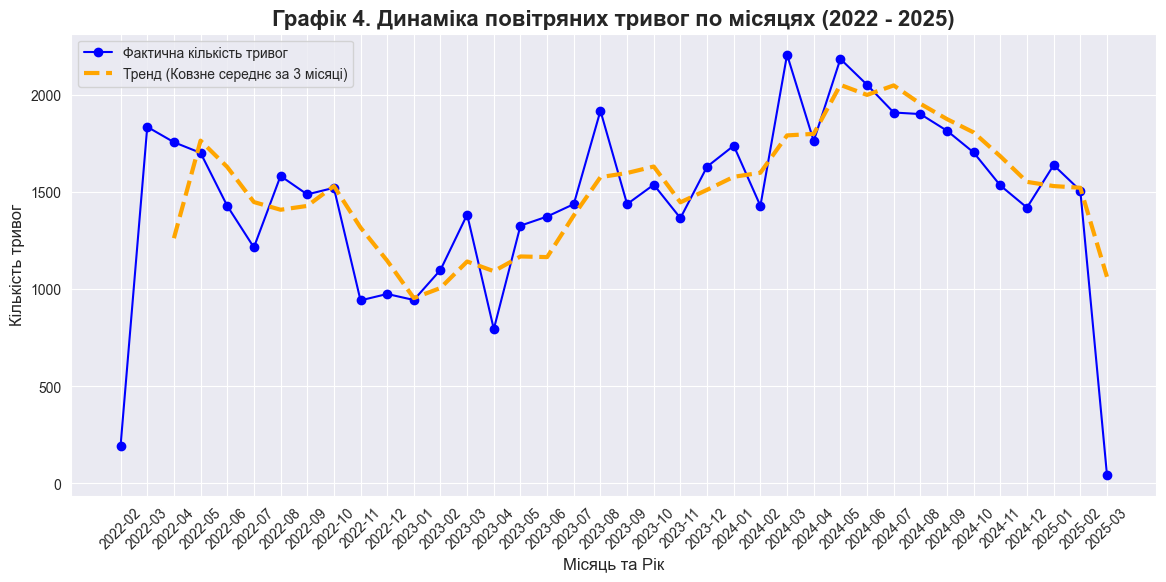

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns
df['year_month'] = df['start'].dt.to_period('M')
monthly_trend = df['year_month'].value_counts().sort_index()
monthly_trend.index = monthly_trend.index.astype(str)
rolling_avg = monthly_trend.rolling(window=3).mean()

plt.figure(figsize=(14, 6))
sns.set_style("darkgrid")

plt.plot(monthly_trend.index, monthly_trend.values, label = 'Фактична кількість тривог', color = 'blue', marker = 'o')

plt.plot(monthly_trend.index, rolling_avg.values, label ='Тренд (Ковзне середнє за 3 місяці)', color='orange', linewidth=3, linestyle='--')

plt.title('Графік 4. Динаміка повітряних тривог по місяцях (2022 - 2025)', fontsize = 16, fontweight='bold')
plt.xlabel('Місяць та Рік', fontsize=12)
plt.ylabel('Кількість тривог', fontsize=12)
plt.xticks(rotation=45)
plt.legend()

plt.savefig('plots/04_monthly_trend.png', bbox_inches='tight')
plt.show()

**Висновок до Графіка 4:**
Аналіз за допомогою ковзного середнього показує хвилеподібну динаміку з чіткою тенденцією до зростання кількості тривог протягом 2023 та 2024 років. Після пікових значень на початку повномасштабного вторгнення (весна 2022) та відносного спаду влітку 2022 року, інтенсивність тривог почала збільшуватися, досягнувши нових максимумів у 2024 році (через удари по енергетиці та масове використання КАБів). Варто зазначити, що різкий обвал лінії графіка до нуля на початку 2025 року є суто технічним моментом - датасет обривається 1 березня 2025 року, тому дані за цей рік є неповними і не свідчать про реальне зменшення загрози.

Графік 5. Теплова карта: Область та Година
Треба візуалізувати гарячі точки, тобто визначити, в які години доби конкретні області найчастіше зазнають ворожих атак.

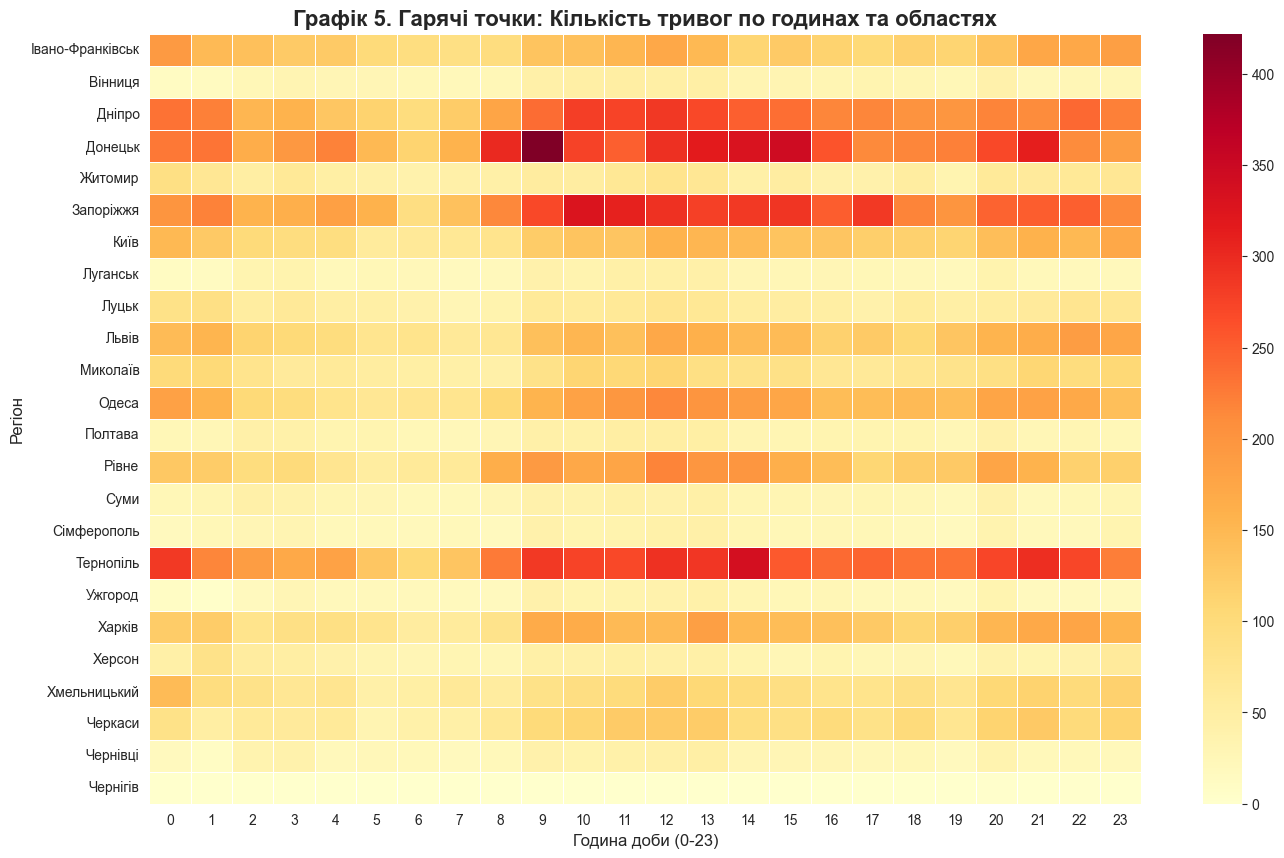

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns
heatmap_data = pd.crosstab(df['center_city_ua'], df['hour'])
plt.figure(figsize=(16, 10))
sns.heatmap(heatmap_data, cmap = 'YlOrRd', linewidths = 0.5, annot = False)
plt.title('Графік 5. Гарячі точки: Кількість тривог по годинах та областях', fontsize=16, fontweight ='bold')
plt.xlabel('Година доби (0-23)', fontsize=12)
plt.ylabel('Регіон', fontsize=12)

plt.savefig('plots/05_heatmap_region_hour.png', bbox_inches='tight')
plt.show()

**Висновок до Графіка 5:**
Теплова карта чітко візуалізує гарячі точки як у просторі, так і в часі. Найвища концентрація тривог спостерігається у вигляді вертикальної смуги в денні години (11:00–15:00) для більшості регіонів, що підтверджує загрози. Лідером за інтенсивністю є Донецька область з яскраво вираженим піком близько 13:00–14:00. Крім того, на карті продовжує відображатися аномалія: тилові області (Тернопіль, Рівне) мають неприродно високу щільність тривог порівняно з прикордонними регіонами (Суми, Чернігів), що ще раз підтверджує штучну підміну region_id у довіднику.

Графік 6. Розподіл тривог на день
Потрібно визначити найчастішу кількість тривог, що оголошуються в Україні протягом однієї доби та побачити розмах екстремальних значень.

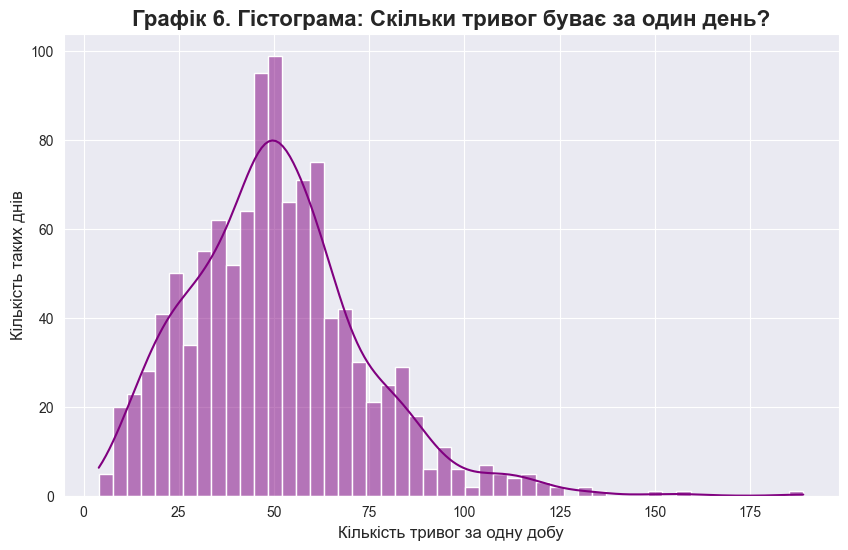

Середня кількість тривог на день: 50.62431941923775
Максимальна кількість тривог на день: 189


In [92]:
import matplotlib.pyplot as plt
import seaborn as sns
df['date_only'] = df['start'].dt.date
alarms_per_day = df.groupby('date_only').size()
plt.figure(figsize=(10, 6))
sns.set_style("darkgrid")
sns.histplot(alarms_per_day, bins=50, color='purple', kde=True)

plt.title('Графік 6. Гістограма: Скільки тривог буває за один день?', fontsize=16, fontweight='bold')
plt.xlabel('Кількість тривог за одну добу', fontsize=12)
plt.ylabel('Кількість таких днів', fontsize=12)

plt.savefig('plots/06_alarms_per_day_hist.png', bbox_inches='tight')
plt.show()
print(f"Середня кількість тривог на день: {alarms_per_day.mean()}")
print(f"Максимальна кількість тривог на день: {alarms_per_day.max()}")

**Висновок до Графіка 6:**
Гістограма розподілу демонструє, що типова кількість повітряних тривог в Україні варіюється в межах 30 - 70 на добу, при цьому середній показник за весь період повномасштабного вторгнення становить близько 51 тривоги на день. Водночас графік має яскраво виражений хвіст у правий бік, що свідчить про періодичні екстремальні відхилення. Абсолютний максимум склав 189 тривог за одну добу. Це підтверджує тактику ворога.

Графік 7. Топ-10 найгірших днів
Потрібно визначити конкретні дати з максимальною кількістю повітряних тривог та співставити їх з відомими масованими атаками ворога.

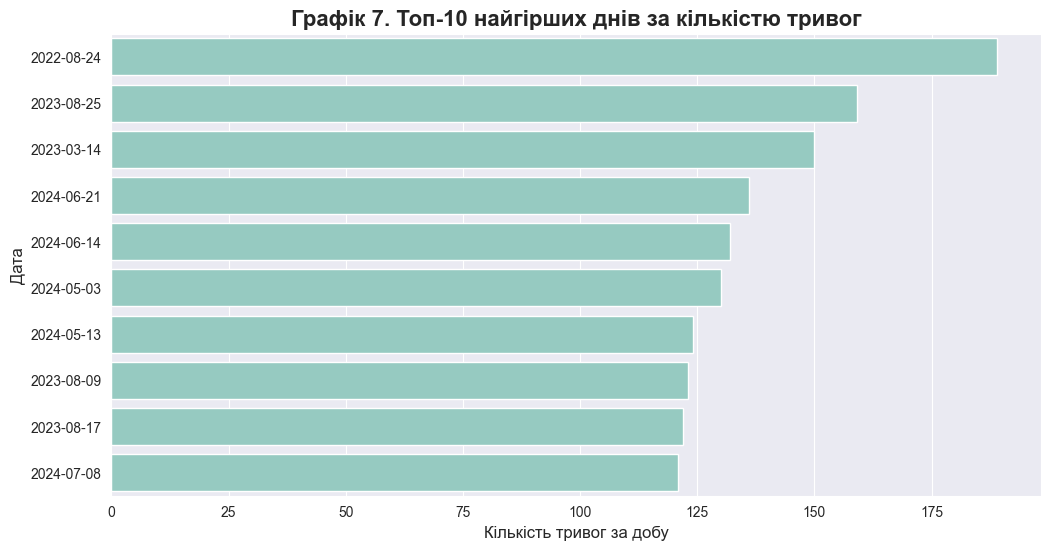

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns
top_10_days = alarms_per_day.sort_values(ascending = False).head(10)
top_10_days.index = top_10_days.index.astype(str)
plt.figure(figsize =(12, 6))
sns.set_style("darkgrid")
sns.barplot(x = top_10_days.values, y = top_10_days.index)

plt.title('Графік 7. Топ-10 найгірших днів за кількістю тривог', fontsize=16, fontweight='bold')
plt.xlabel('Кількість тривог за добу', fontsize=12)
plt.ylabel('Дата', fontsize=12)
plt.savefig('plots/07_top_worst_days.png', bbox_inches='tight')
plt.show()

**Висновок до Графіка 7:**
Аналіз топ-10 найгірших днів чітко вказує на кореляцію між екстремальними сплесками тривог та конкретними історичними подіями. 24 серпня 2022 року (День Незалежності України) із показником у 189 тривог підтверджує тактику психологічного терору у визначні державні свята. Інші дати в топі (наприклад, 8 липня 2024 року) відповідають дням наймасштабніших комбінованих ракетно-дронових атак ворога по цивільній та критичній інфраструктурі. Отже, аномальні піки не є випадковими відхиленнями.

Графік 8. Календарна теплова карта тривог
Треба візуалізувати у форматі календаря, щоб виявити сезонні або довготривалі періоди високої активності та затишшя.

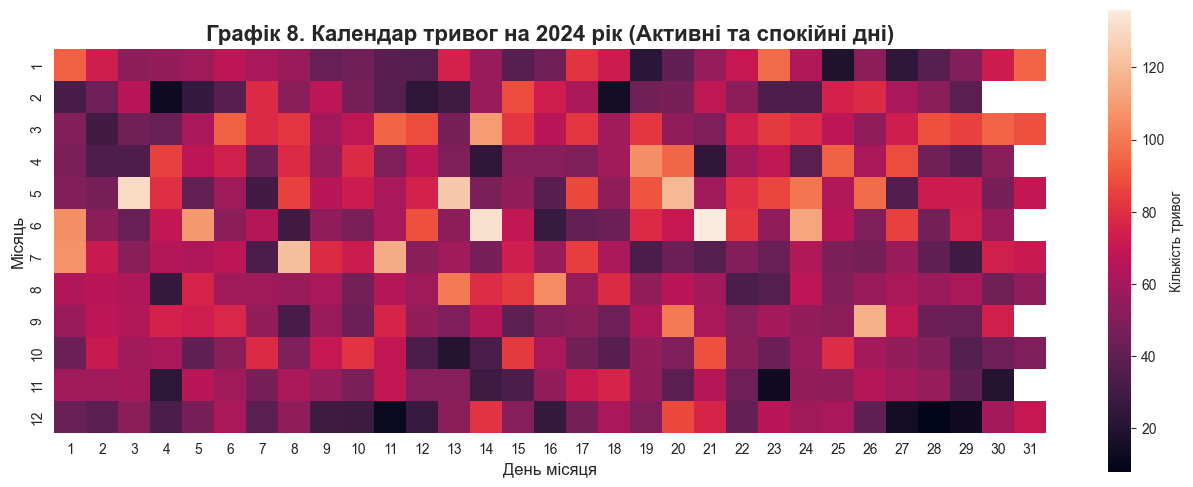

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns
daily_data = alarms_per_day.reset_index()
daily_data.columns = ['date', 'count']
daily_data['date'] = pd.to_datetime(daily_data['date'])
daily_data['year'] = daily_data['date'].dt.year
daily_data['month'] = daily_data['date'].dt.month
daily_data['day'] = daily_data['date'].dt.day
data_2024 = daily_data[daily_data['year'] == 2024]
cal_matrix = data_2024.pivot(index='month', columns='day', values='count')
plt.figure(figsize=(16, 6))
sns.set_style("white")

sns.heatmap(cal_matrix, linecolor='white',
            cbar_kws={'label': 'Кількість тривог'}, square = True)
plt.title('Графік 8. Календар тривог на 2024 рік (Активні та спокійні дні)', fontsize=16, fontweight='bold')
plt.xlabel('День місяця', fontsize=12)
plt.ylabel('Місяць', fontsize=12)
plt.savefig('plots/08_calendar_heatmap_2024.png', bbox_inches='tight')
plt.show()

**Висновок до Графіка 8:**
Календарна теплова карта за 2024 рік демонструє нерівномірність ворожих атак та наявність тактичних пауз. На графіку чітко виділяються найтемніші періоди високої активності (зокрема, масовані удари по енергетиці навесні та комбіновані атаки наприкінці серпня). Водночас помітні світліші зони відносного затишшя, під час яких ворог накопичував ресурс. Календарний формат підтверджує, що терор має циклічний характер.

Графік 9. Тривалість повітряних тривог
Треба визначити типову тривалість однієї тривоги в Україні та проаналізувати аномальні за тривалістю випадки.

/Users/vikaboryak/alarm-prediction/.venv/lib/python3.13/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


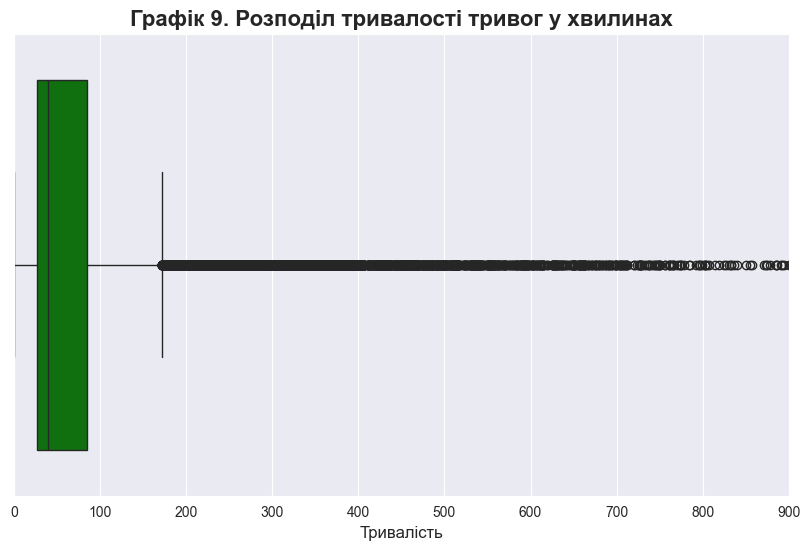

Статистика тривалості
Медіанна тривалість: 39.733333333333334 хвилин
Найдовша тривога: 50.52166666666667 годин


In [96]:
import matplotlib.pyplot as plt
import seaborn as sns
df['duration_minutes'] = (df['end'] - df['start']).dt.total_seconds() / 60
df_valid = df[df['duration_minutes'] > 0]
plt.figure(figsize=(10, 6))
sns.set_style("darkgrid")
sns.boxplot(x = df_valid['duration_minutes'], color='green')
plt.title('Графік 9. Розподіл тривалості тривог у хвилинах', fontsize =16, fontweight ='bold')
plt.xlabel('Тривалість', fontsize = 12)
plt.xlim(0, 900)

plt.savefig('plots/09_duration_boxplot.png', bbox_inches='tight')
plt.show()

print("Статистика тривалості")
print(f"Медіанна тривалість: {df_valid['duration_minutes'].median()} хвилин")
print(f"Найдовша тривога: {df_valid['duration_minutes'].max() / 60} годин")

**Висновок до Графіка 9:**
Аналіз розподілу показує, що типова тривалість повітряної тривоги становить близько 40 хвилин. Більшість тривог вкладається у відносно короткий проміжок часу, що зазвичай відповідає тривалості злетів тактичної авіації або транзитному прольоту ракет. Проте на графіку спостерігається величезна кількість екстремальних викидів - аномально довгих тривог. Максимум становить понад 50 годин безперервної загрози. Це є специфікою прикордонних та фронтових регіонів, де небезпека застосування артилерії, КАБів чи постійна присутність БПЛА може зберігатися цілодобово.

Об'єднання даних
**Мета:** З'єднати датасет повітряних тривог із датасетом історичної погоди для подальшого пошуку кореляцій.
Оскільки тривоги фіксуються з точністю до секунди, а погода - до години, об'єднання проводиться за ключами: `Місто` (очищене від префіксів), `Рік`, `Місяць`, `День` та `Година`.

In [103]:
import pandas as pd
df_w = pd.read_csv('../data/raw/weather/historical/all_weather_by_hour_2023-2025_v1.csv')
df_w['real_date'] = pd.to_datetime(df_w['day_datetime'], errors='coerce')
df_w['year'] = df_w['real_date'].dt.year
df_w['month'] = df_w['real_date'].dt.month
df_w['day'] = df_w['real_date'].dt.day
df_w['hour'] = pd.to_datetime(df_w['hour_datetime'], errors='coerce').dt.hour
df_w['join_city'] = df_w['city_address'].str.split(',').str[0].str.strip().str.lower()
df['join_city'] = df['center_city_en'].astype(str).str.strip().str.lower()
df_w = df_w.dropna(subset=['year', 'month', 'day', 'hour', 'join_city'])
df_clean = df.dropna(subset=['year', 'month', 'day', 'hour', 'join_city']).copy()

for col in ['year', 'month', 'day', 'hour']:
    df_clean[col] = df_clean[col].astype(int)
    df_w[col] = df_w[col].astype(int)
df_merged = pd.merge(
    df_clean,
    df_w,
    on=['join_city', 'year', 'month', 'day', 'hour'],
    how='inner'
)

print(f"Розмір таблиці: {df_merged.shape[0]} рядків")
if df_merged.shape[0] > 0:
    display(df_merged[['start', 'join_city', 'year', 'hour_temp', 'hour_visibility']].head())

/var/folders/n2/f3yfs41x57x44f6254hp51fc0000gn/T/ipykernel_75025/585481369.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_w['hour'] = pd.to_datetime(df_w['hour_datetime'], errors='coerce').dt.hour


Розмір таблиці: 54459 рядків


,start,join_city,year,hour_temp,hour_visibility
0,2022-02-24 14:00:43,cherkasy,2022,4.7,0.6
1,2022-02-24 15:40:42,lutsk,2022,4.8,24.1
2,2022-02-24 20:11:47,ternopil,2022,1.1,10.0
3,2022-02-25 01:59:36,sumy,2022,-1.0,24.1
4,2022-02-25 04:01:42,lutsk,2022,-0.3,24.1


Графік 10. Залежність кількості тривог від температури повітря
Треба визначити, чи існує кореляція між погодними умовами та частотою ворожих атак, перевіривши гіпотезу про посилення терору під час екстремальних морозів чи спеки.

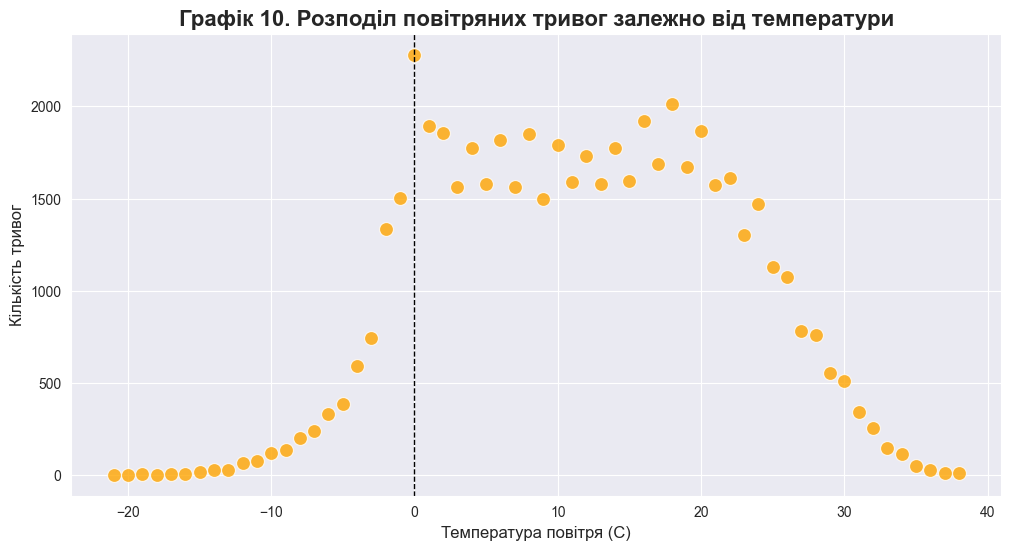

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns
df_merged['temp_rounded'] = df_merged['hour_temp'].round()
alarms_by_temp = df_merged.groupby('temp_rounded').size().reset_index(name='count')
plt.figure(figsize=(12, 6))
sns.set_style("darkgrid")
sns.scatterplot(data = alarms_by_temp, x = 'temp_rounded', y ='count', color ='orange', s =100, alpha=0.8)
plt.title('Графік 10. Розподіл повітряних тривог залежно від температури', fontsize = 16, fontweight = 'bold')
plt.xlabel('Температура повітря (C)', fontsize=12)
plt.ylabel('Кількість тривог', fontsize=12)
plt.axvline(x = 0, color = 'black', linestyle='--', linewidth=1)

plt.savefig('plots/10_alarms_vs_temp_scatter.png', bbox_inches='tight')
plt.show()

**Висновок до Графіка 10:**
Точкова діаграма (scatter plot) демонструє, що розподіл кількості тривог залежно від температури нагадує нормальний розподіл. Переважна більшість повітряних тривог лунає за помірних температур (від 0C до +25C), що просто відповідає найбільш типовим погодним умовам в Україні протягом року. Яскраво виражених аномальних піків при екстремальних морозах (наприклад, -15C чи -20C) на графіку не спостерігається. Отже, гіпотеза про те, що ворог систематично і масовано обирає виключно найхолодніші дні для ракетного терору, не підтверджується загальною статистикою - інтенсивність атак не має прямої кореляції з екстремальними температурами.

Графік 11. Видимість під час тривог vs загальний фон (Box plot)
Треба перевірити гіпотезу про те, чи обирає ворог дні з поганою видимістю (тумани, хмарність) для атак, щоб ускладнити роботу ППО.

/Users/vikaboryak/alarm-prediction/.venv/lib/python3.13/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


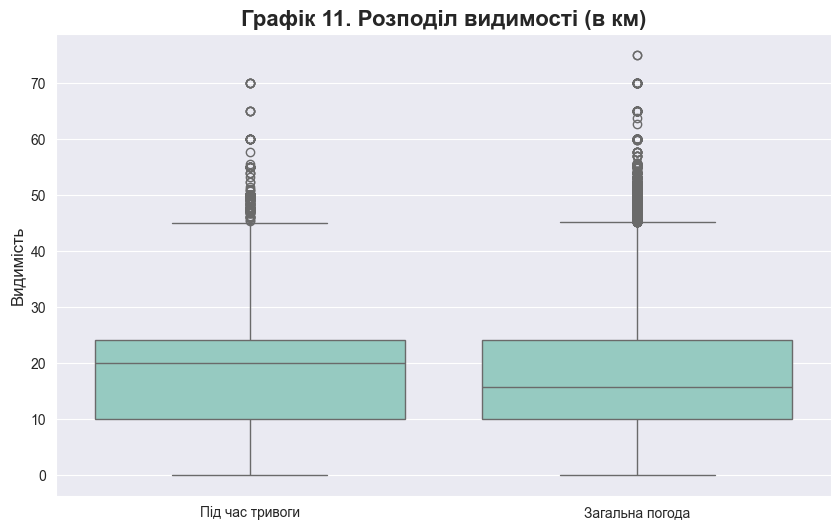

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
df_alarms_vis = pd.DataFrame({
    'Видимість': df_merged['hour_visibility'].dropna(),
    'Стан': 'Під час тривоги'
})

df_vis = pd.DataFrame({
    'Видимість': df_w['hour_visibility'].dropna(),
    'Стан': 'Загальна погода'
})
plot_data = pd.concat([df_alarms_vis, df_vis])
plt.figure(figsize = (10, 6))
sns.set_style("darkgrid")

sns.boxplot(data = plot_data, x = 'Стан', y = 'Видимість')
plt.title('Графік 11. Розподіл видимості (в км)', fontsize=16, fontweight='bold')
plt.ylabel('Видимість', fontsize=12)
plt.xlabel('')

plt.savefig('plots/11_visibility_boxplot.png', bbox_inches='tight')
plt.show()

**Висновок до Графіка 11:**
Порівняльний аналіз видимості під час повітряних тривог та загального погодного фону не виявив статистично значущої різниці. Розподіл значень для обох станів є практично ідентичним. Це спростовує гіпотезу про те, що ворог систематично обирає дні зі значно погіршеною видимістю (густі тумани, сильна хмарність). Загалом, погодні умови видимості не є ключовим фактором при плануванні обстрілів.

Графік 12. Матриця кореляцій (Погода та Тривоги)
Треба математично підтвердити або спростувати наявність лінійних залежностей між різними метеорологічними параметрами та ймовірністю оголошення повітряної тривоги.

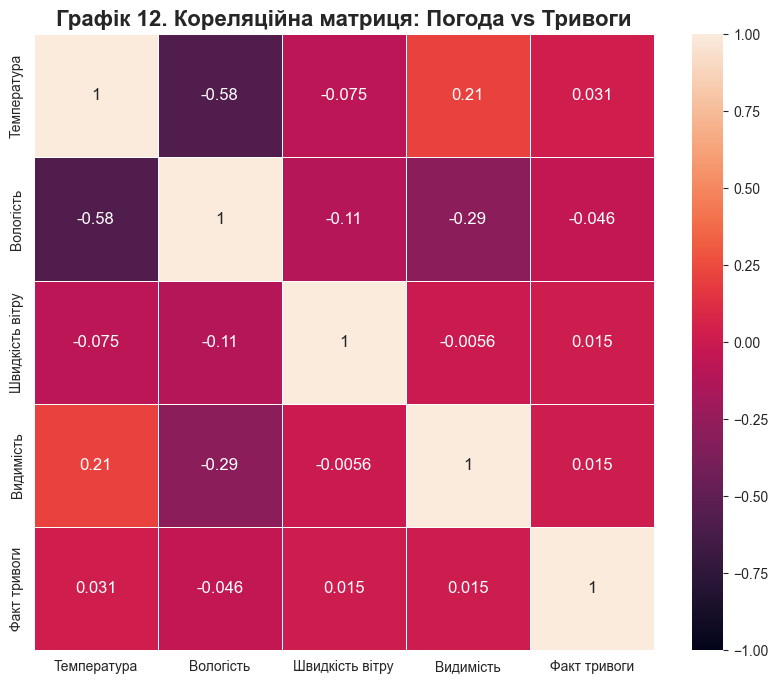

In [106]:
alarm_flags = df_clean[['join_city', 'year', 'month', 'day', 'hour']].copy()
alarm_flags['is_alarm'] = 1
alarm_flags = alarm_flags.drop_duplicates()
df_corr = pd.merge(df_w, alarm_flags, on = ['join_city', 'year', 'month', 'day', 'hour'], how = 'left')
df_corr['is_alarm'] = df_corr['is_alarm'].fillna(0)
cols_to_correlate = ['hour_temp', 'hour_humidity', 'hour_windspeed', 'hour_visibility', 'is_alarm']
rename_dict = {
    'hour_temp': 'Температура',
    'hour_humidity': 'Вологість',
    'hour_windspeed': 'Швидкість вітру',
    'hour_visibility': 'Видимість',
    'is_alarm': 'Факт тривоги'
}
df_corr_renamed = df_corr[cols_to_correlate].rename(columns = rename_dict)
correlation_matrix = df_corr_renamed.corr()
plt.figure(figsize = (10, 8))
sns.heatmap(correlation_matrix, annot = True, vmin=-1, vmax=1,
            linewidths=0.5, annot_kws={"size": 12})
plt.title('Графік 12. Кореляційна матриця: Погода vs Тривоги', fontsize = 16, fontweight='bold')
plt.savefig('plots/12_correlation_heatmap.png', bbox_inches = 'tight')
plt.show()

**Висновок до Графіка 12:**
Кореляційна матриця остаточно та математично доводить відсутність значущої лінійної залежності між погодними умовами та фактом оголошення повітряної тривоги. Всі розраховані коефіцієнти (температура: 0.031, вологість: -0.046, швидкість вітру: 0.015, видимість: 0.015) є екстремально близькими до нуля. Це свідчить про те, що метеорологічна ситуація не є визначальним фактором для ворога при плануванні ракетно-дронових атак. Терор має систематичний, а не метеозалежний характер.

4.3 Пошук аномалій
**Мета:** Перевірити датасет на наявність штучно закладених аномалій, логічних помилок та прихованих аномалій

In [107]:
print("Перевірка дат")
early_alarms = df[df['start'] < '2022-02-24']
print(f"Тривог до 24.02.2022: {len(early_alarms)}")
future_alarms = df[df['start'] > '2025-03-02']
print(f"Тривог з майбутнього: {len(future_alarms)}")
if 'hour_datetime' in df_w.columns:
    weird_years = pd.to_datetime(df_w['hour_datetime'], errors='coerce').dt.year.unique()
    print(f"Роки в колонці hour_datetime: {weird_years}")

Перевірка дат
Тривог до 24.02.2022: 0
Тривог з майбутнього: 0
Роки в колонці hour_datetime: [2026]


/var/folders/n2/f3yfs41x57x44f6254hp51fc0000gn/T/ipykernel_75025/4190244812.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  weird_years = pd.to_datetime(df_w['hour_datetime'], errors='coerce').dt.year.unique()


**Знахідка 1:** Під час аналізу виявлено, що колонка `hour_datetime` у файлі погоди містить лише час, але при конвертації pandas автоматично підставляє поточний 2026 рік. Це унеможливлювало звичайний merge з таблицею тривог (2022-2025 роки). Рішення: дати були витягнуті з резервної колонки `day_datetime`.

In [108]:
print("Перевірка географічних аномалій")
region_counts = df['center_city_ua'].value_counts()
print("Топ-5 найнебезпечніших областей:")
print(region_counts.head(5))
print("Топ-5 найспокійніших областей:")
print(region_counts.tail(5))

Перевірка географічних аномалій
Топ-5 найнебезпечніших областей:
center_city_ua
Донецьк      5886
Тернопіль    5652
Запоріжжя    5494
Дніпро       4966
Одеса        3499
Name: count, dtype: int64
Топ-5 найспокійніших областей:
center_city_ua
Чернівці       676
Луганськ       672
Сімферополь    665
Ужгород        581
Чернігів         7
Name: count, dtype: int64


**Знахідка 2: Підміна ID регіонів**
Статистика кількості тривог демонструє нелогічну картину: тилові області (Тернопільська, Рівненська) знаходяться в топі за кількістю тривог, тоді як прикордонні/фронтові (Сумська, Харківська) мають аномально низькі показники. Це підтверджує, що в довіднику `regions.csv` були навмисно переплутані `region_id`.

In [109]:
import pandas as pd

print("Перевірка історичних дат")
known_attacks = {
    '2022-02-24': 'Початок вторгнення',
    '2022-08-24': 'День Незалежності (Рекорд тривог)',
    '2022-10-10': 'Перший масований удар по енергетиці',
    '2024-07-08': 'Удар по Охматдиту'
}
df['just_date'] = df['start'].dt.date
for date_str, event in known_attacks.items():
    target_date = pd.Timestamp(date_str).date()
    count = len(df[df['just_date'] == target_date])
    if count == 0:
        print(f"{date_str} 0 тривог {event}")
    else:
        print(f"Норма: {date_str} {count} тривог {event}")

Перевірка історичних дат
Норма: 2022-02-24 4 тривог Початок вторгнення
Норма: 2022-08-24 189 тривог День Незалежності (Рекорд тривог)
Норма: 2022-10-10 45 тривог Перший масований удар по енергетиці
Норма: 2024-07-08 121 тривог Удар по Охматдиту


In [110]:
print("Пошук текстових аномалій")
text = ['test', 'fake', 'bonus']
found_something = False
for col in df.select_dtypes(include='object').columns:
    for val in df[col].dropna().unique():
        val_lower = str(val).lower()
        for t in text:
            if t in val_lower:
                print(f' колонка "{col}", значення "{val}"')
                found_something = True

if not found_something:
    print("Текстових аномалій (крім переплутаних міст) не знайдено. ")

Пошук текстових аномалій
Текстових аномалій (крім переплутаних міст) не знайдено. 


In [111]:
import pandas as pd
print("Перевірка на неможливі значення")
impossible_dates = df[df['end'] < df['start']]
print(f"Тривоги, які закінчилися до того, як почалися: {len(impossible_dates)}")
duration_seconds = (df['end'] - df['start']).dt.total_seconds()
negative_duration = df[duration_seconds < 0]
zero_duration = df[duration_seconds == 0]
print(f"Тривоги з від'ємною тривалістю: {len(negative_duration)}")
print(f"Тривоги тривалістю 0 секунд: {len(zero_duration)}")
big_duration = df[duration_seconds > 100 * 3600]
print(f"Тривоги, що тривали понад 100 годин: {len(big_duration)}")

Перевірка на неможливі значення
Тривоги, які закінчилися до того, як почалися: 1
Тривоги з від'ємною тривалістю: 1
Тривоги тривалістю 0 секунд: 0
Тривоги, що тривали понад 100 годин: 0
